# Redes Neurais de Base Radial (RBF) - Atividade 06

Classificação de radiação utilizando clusterização por k-means e treinamento da camada de saída com regra delta.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

### Dados de Treinamento e Teste

In [12]:
X_train = np.array([[0.2563, 0.9503], [0.2405, 0.9018], [0.1157, 0.3676], [0.5147, 0.0167], [0.4127, 0.3275], [0.2809, 0.583], [0.8263, 0.9301], [0.9359, 0.8724], [0.1096, 0.9165], [0.5158, 0.8545], [0.1334, 0.1362], [0.6371, 0.1439], [0.7052, 0.6277], [0.8703, 0.8666], [0.2612, 0.6109], [0.0244, 0.5279], [0.9588, 0.3672], [0.9332, 0.5499], [0.9623, 0.2961], [0.7297, 0.5776], [0.456, 0.1871], [0.1715, 0.7713], [0.5571, 0.5485], [0.3344, 0.0259], [0.4803, 0.7635], [0.9721, 0.485], [0.8318, 0.7844], [0.1373, 0.0292], [0.366, 0.8581], [0.3626, 0.7302], [0.6474, 0.3324], [0.3461, 0.2398], [0.1353, 0.812], [0.3463, 0.1017], [0.9086, 0.1947], [0.5227, 0.2321], [0.5153, 0.2041], [0.1832, 0.0661], [0.5015, 0.9812], [0.5024, 0.5274]])
D_train = np.array([-1.0, -1.0, 1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0, -1.0, 1.0, 1.0, -1.0, -1.0, 1.0, 1.0, -1.0, -1.0, -1.0, -1.0, 1.0, 1.0, -1.0, 1.0, -1.0, -1.0, -1.0, 1.0, -1.0, -1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 1.0, 1.0, 1.0, -1.0, -1.0])

X_test = np.array([[0.8705, 0.9329], [0.0388, 0.2703], [0.8236, 0.4458], [0.7075, 0.1502], [0.9587, 0.8663], [0.6115, 0.9365], [0.3534, 0.3646], [0.3268, 0.2766], [0.6129, 0.4518], [0.9948, 0.4962]])
D_test = np.array([-1.0, 1.0, -1.0, 1.0, -1.0, -1.0, 1.0, 1.0, -1.0, -1.0])

### Funções Auxiliares

In [13]:
def gaussian(X, centers, variances):
    H = np.zeros((X.shape[0], len(centers)))
    for i in range(len(centers)):
        H[:, i] = np.exp(-np.linalg.norm(X - centers[i], axis=1)**2 / (2 * variances[i]))
    return H

### Resultados da Camada Oculta

In [14]:
centers = np.array([[0.1648333333333333, 0.6121166666666666], [0.3989692307692308, 0.15713076923076919]])
variances = np.array([0.02980551027777778, 0.038459862721893494])
print('Centros:\n', centers)
print('Variâncias:\n', variances)

Centros:
 [[0.16483333 0.61211667]
 [0.39896923 0.15713077]]
Variâncias:
 [0.02980551 0.03845986]


### Gráfico de Erro

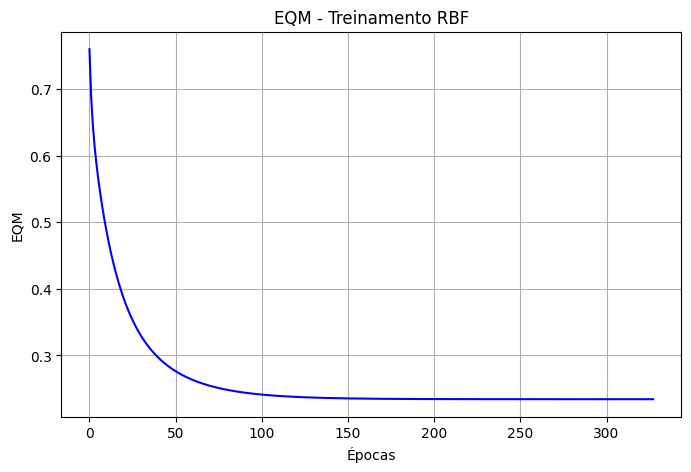

In [15]:
eqm_history = [np.float64(0.7602145747320759), np.float64(0.6888322195908648), np.float64(0.644974040945532), np.float64(0.6137866724852827), np.float64(0.5888825261718953), np.float64(0.567467182329725), np.float64(0.5482796298688719), np.float64(0.5307191101323617), np.float64(0.5144734211102389), np.float64(0.4993596876839879), np.float64(0.48525549080969627), np.float64(0.4720686346253922), np.float64(0.45972356582545026), np.float64(0.4481550518752583), np.float64(0.4373050755746804), np.float64(0.4271211885067065), np.float64(0.4175555484849324), np.float64(0.40856429273152883), np.float64(0.40010708621267665), np.float64(0.3921467686084375), np.float64(0.3846490619028705), np.float64(0.3775823187349453), np.float64(0.37091730050722316), np.float64(0.36462697874177524), np.float64(0.3586863555513765), np.float64(0.3530723004119361), np.float64(0.3477634011879347), np.float64(0.342739827830269), np.float64(0.33798320746669075), np.float64(0.33347650980923105), np.float64(0.32920394194939606), np.float64(0.3251508517225104), np.float64(0.32130363891015884), np.float64(0.3176496736218243), np.float64(0.31417722125816816), np.float64(0.3108753735117899), np.float64(0.3077339849085837), np.float64(0.3047436144351637), np.float64(0.301895471836089), np.float64(0.29918136819936086), np.float64(0.29659367048033103), np.float64(0.2941252596430916), np.float64(0.29176949212488273), np.float64(0.2895201643533065), np.float64(0.2873714800683499), np.float64(0.2853180202216006), np.float64(0.28335471524372335), np.float64(0.2814768194884095), np.float64(0.279679887676737), np.float64(0.2779597531803103), np.float64(0.2763125079947885), np.float64(0.27473448426756064), np.float64(0.2732222372544727), np.float64(0.2717725295907446), np.float64(0.2703823167706013), np.float64(0.26904873373875754), np.float64(0.2677690825048049), np.float64(0.26654082069880075), np.float64(0.2653615509930244), np.float64(0.2642290113209724), np.float64(0.26314106583027674), np.float64(0.2620956965113794), np.float64(0.2610909954485188), np.float64(0.2601251576439269), np.float64(0.2591964743701117), np.float64(0.25830332700875847), np.float64(0.2574441813381397), np.float64(0.2566175822339981), np.float64(0.25582214875170345), np.float64(0.25505656956007206), np.float64(0.2543195986996284), np.float64(0.25361005164027206), np.float64(0.25292680161532827), np.float64(0.2522687762108005), np.float64(0.251634954190343), np.float64(0.2510243625380269), np.float64(0.2504360737024013), np.float64(0.24986920302666665), np.float64(0.2493229063509835), np.float64(0.24879637777404634), np.float64(0.24828884756207364), np.float64(0.24779958019429732), np.float64(0.24732787253489746), np.float64(0.2468730521221158), np.float64(0.24643447556600995), np.float64(0.24601152704697524), np.float64(0.24560361690777643), np.float64(0.24521018033239467), np.float64(0.2448306761055142), np.float64(0.24446458544694855), np.float64(0.24411141091574812), np.float64(0.24377067537912972), np.float64(0.24344192104174395), np.float64(0.24312470853113483), np.float64(0.2428186160355617), np.float64(0.24252323849064322), np.float64(0.24223818681154646), np.float64(0.24196308716769338), np.float64(0.24169758029717894), np.float64(0.24144132085830536), np.float64(0.2411939768158268), np.float64(0.2409552288596771), np.float64(0.24072476985411329), np.float64(0.2405023043153594), np.float64(0.24028754791597326), np.float64(0.2400802270142846), np.float64(0.2398800782073725), np.float64(0.239686847906157), np.float64(0.23950029193128114), np.float64(0.23932017512855142), np.float64(0.23914627100278954), np.float64(0.23897836136902817), np.float64(0.23881623602005647), np.float64(0.2386596924093868), np.float64(0.23850853534877822), np.float64(0.23836257671950936), np.float64(0.23822163519664583), np.float64(0.23808553598559817), np.float64(0.23795411057031113), np.float64(0.23782719647246697), np.float64(0.237704637021126), np.float64(0.2375862811322639), np.float64(0.2374719830976974), np.float64(0.23736160238292342), np.float64(0.23725500343342526), np.float64(0.23715205548902532), np.float64(0.2370526324058913), np.float64(0.23695661248582325), np.float64(0.236863878312474), np.float64(0.23677431659417292), np.float64(0.23668781801304317), np.float64(0.23660427708012072), np.float64(0.23652359199619824), np.float64(0.23644566451813392), np.float64(0.2363703998303789), np.float64(0.23629770642148945), np.float64(0.2362274959654053), np.float64(0.23615968320728337), np.float64(0.23609418585369105), np.float64(0.23603092446696952), np.float64(0.23596982236359182), np.float64(0.2359108055163442), np.float64(0.2358538024601719), np.float64(0.2357987442015374), np.float64(0.23574556413114464), np.float64(0.23569419793989255), np.float64(0.23564458353792625), np.float64(0.23559666097666127), np.float64(0.23555037237366072), np.float64(0.23550566184025296), np.float64(0.23546247541178067), np.float64(0.23542076098037806), np.float64(0.2353804682301776), np.float64(0.2353415485748517), np.float64(0.2353039550973996), np.float64(0.23526764249209248), np.float64(0.23523256700849543), np.float64(0.2351986863974859), np.float64(0.2351659598591948), np.float64(0.23513434799279653), np.float64(0.23510381274807918), np.float64(0.23507431737872833), np.float64(0.2350458263972614), np.float64(0.23501830553155015), np.float64(0.23499172168287377), np.float64(0.23496604288544662), np.float64(0.2349412382673653), np.float64(0.23491727801292467), np.float64(0.23489413332625234), np.float64(0.23487177639621343), np.float64(0.23485018036254077), np.float64(0.23482931928314565), np.float64(0.23480916810256644), np.float64(0.23478970262151502), np.float64(0.2347708994674811), np.float64(0.23475273606635713), np.float64(0.23473519061504694), np.float64(0.234718242055024), np.float64(0.23470187004680435), np.float64(0.23468605494530345), np.float64(0.23467077777604411), np.float64(0.23465602021218662), np.float64(0.2346417645523517), np.float64(0.23462799369920825), np.float64(0.2346146911387997), np.float64(0.23460184092058195), np.float64(0.2345894276381495), np.float64(0.23457743641062406), np.float64(0.23456585286468418), np.float64(0.23455466311721213), np.float64(0.2345438537585373), np.float64(0.23453341183625542), np.float64(0.2345233248396031), np.float64(0.23451358068436878), np.float64(0.23450416769832155), np.float64(0.23449507460713948), np.float64(0.23448629052082062), np.float64(0.23447780492055964), np.float64(0.23446960764607433), np.float64(0.23446168888336616), np.float64(0.2344540391528998), np.float64(0.23444664929818765), np.float64(0.23443951047476497), np.float64(0.2344326141395423), np.float64(0.23442595204052213), np.float64(0.2344195162068675), np.float64(0.23441329893930982), np.float64(0.23440729280088543), np.float64(0.23440149060798796), np.float64(0.23439588542172712), np.float64(0.23439047053958278), np.float64(0.23438523948734374), np.float64(0.23438018601132266), np.float64(0.23437530407083612), np.float64(0.23437058783094233), np.float64(0.23436603165542613), np.float64(0.23436163010002392), np.float64(0.23435737790588015), np.float64(0.2343532699932264), np.float64(0.23434930145527705), np.float64(0.23434546755233301), np.float64(0.23434176370608623), np.float64(0.23433818549411972), np.float64(0.23433472864459376), np.float64(0.23433138903111478), np.float64(0.23432816266777837), np.float64(0.23432504570438165), np.float64(0.2343220344217994), np.float64(0.23431912522751733), np.float64(0.23431631465131791), np.float64(0.23431359934111332), np.float64(0.23431097605892076), np.float64(0.23430844167697465), np.float64(0.2343059931739714), np.float64(0.2343036276314428), np.float64(0.2343013422302521), np.float64(0.23429913424721055), np.float64(0.23429700105180878), np.float64(0.23429494010305957), np.float64(0.2342929489464483), np.float64(0.23429102521098769), np.float64(0.2342891666063724), np.float64(0.23428737092023105), np.float64(0.23428563601547178), np.float64(0.23428395982771838), np.float64(0.2342823403628332), np.float64(0.23428077569452554), np.float64(0.23427926396204066), np.float64(0.23427780336792808), np.float64(0.23427639217588533), np.float64(0.23427502870867628), np.float64(0.234273711346119), np.float64(0.2342724385231433), np.float64(0.2342712087279139), np.float64(0.23427002050001802), np.float64(0.23426887242871378), np.float64(0.23426776315123968), np.float64(0.2342666913511804), np.float64(0.23426565575688896), np.float64(0.2342646551399626), np.float64(0.23426368831377026), np.float64(0.2342627541320307), np.float64(0.23426185148743855), np.float64(0.23426097931033746), np.float64(0.23426013656743866), np.float64(0.23425932226058271), np.float64(0.23425853542554353), np.float64(0.23425777513087379), np.float64(0.23425704047678853), np.float64(0.23425633059408782), np.float64(0.2342556446431156), np.float64(0.2342549818127541), np.float64(0.23425434131945244), np.float64(0.23425372240628853), np.float64(0.2342531243420627), np.float64(0.23425254642042237), np.float64(0.23425198795901628), np.float64(0.2342514482986778), np.float64(0.23425092680263604), np.float64(0.23425042285575354), np.float64(0.23424993586379048), np.float64(0.23424946525269305), np.float64(0.23424901046790705), np.float64(0.23424857097371427), np.float64(0.23424814625259155), np.float64(0.23424773580459188), np.float64(0.23424733914674628), np.float64(0.23424695581248614), np.float64(0.23424658535108572), np.float64(0.23424622732712255), np.float64(0.23424588131995736), np.float64(0.2342455469232309), np.float64(0.23424522374437853), np.float64(0.23424491140416076), np.float64(0.23424460953620993), np.float64(0.23424431778659285), np.float64(0.23424403581338743), np.float64(0.2342437632862747), np.float64(0.23424349988614362), np.float64(0.23424324530471038), np.float64(0.23424299924415024), np.float64(0.2342427614167415), np.float64(0.23424253154452251), np.float64(0.23424230935895923), np.float64(0.23424209460062534), np.float64(0.2342418870188921), np.float64(0.23424168637162932), np.float64(0.23424149242491704), np.float64(0.23424130495276546), np.float64(0.2342411237368462), np.float64(0.2342409485662315), np.float64(0.23424077923714287), np.float64(0.23424061555270798), np.float64(0.23424045732272591), np.float64(0.23424030436344076), np.float64(0.23424015649732213), np.float64(0.23424001355285404), np.float64(0.23423987536433036), np.float64(0.23423974177165735), np.float64(0.2342396126201633), np.float64(0.23423948776041392), np.float64(0.23423936704803472), np.float64(0.23423925034353887), np.float64(0.2342391375121616), np.float64(0.23423902842369934), np.float64(0.2342389229523552), np.float64(0.23423882097658902), np.float64(0.23423872237897303)]

plt.figure(figsize=(8, 5))
plt.plot(eqm_history, color='blue')
plt.title('EQM - Treinamento RBF')
plt.xlabel('Épocas')
plt.ylabel('EQM')
plt.grid(True)
plt.show()